# Project Milestone One: Gathering your Team, Understanding the Problem,  Exploring the Data

#### Due: Midnight on March 29th (with 2-hour grace period)  

#### There will be no late period on this homework, as we need to start manual grading immediately! 



### What We Will Do in This Milestone Assignment

1. You will convene your team and fill out the Team Contract (in the Homework Repo), to be submitted to Gradescope.
2. You must select a team leader for the purpose of submitting this notebook, after the team collaborates to complete the assignment. This <a href=https://guides.gradescope.com/hc/en-us/articles/21863861823373-Adding-Group-Members-to-a-Submission>link</a> describes how to add group members to your leader's submission. 
3. At the conclusion of your work on this Milestone, you will complete an Individual Evaluation of your team's work (in the Homework Repo) and upload it *individually* to Gradescope.
4. We will follow a simplified version of the **Machine Learning Project Checklist** in Appendix A in our textbook *Hands-On Machine Learning* (pp.779):  

>Part 1:	Frame the problem and look at the big picture  
Part 2: Download and perform preliminary exploration of the data  
Part 3: Clean the Data: Drop, Impute, and Encode   
Part 4: Explore Feature Relationships  
Part 5: Investigate Feature Engineering options to better expose the underlying data patterns  

### The Dataset

All teams will use the same dataset. It is a smaller version of the Zillow housing dataset that was used in the
Zillow Million Dollar Prize which ran on Kaggle in 2017 (sorry, the contest is closed, so you can't win any money
with this project!).  We will try to predict the assessed tax value (`'taxvaluedollarcnt'`) of the property from a large collection
of descriptors. Some features are closely related and some are obviously useless.  There are potential outliers and also quite a few missing values. 

This is a good example of a dataset which has not been predigested for you on Kaggle, and should give you a good chance to
try all the various tools in your toolbox!


In [73]:
# =============================
# Useful Imports
# =============================
!pip install numpy
!pip install pandas
!pip install seaborn
!pip install matplotlib.pyplot
!pip install matplotlib.patches
!pip install matplotlib.ticker
!pip install scikit-learn
!pip install tqdm

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))




[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
ERROR: Could not find a version that satisfies the requirement matplotlib.pyplot (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
ERROR: No matching distribution found for matplotlib.pyplot
ERROR: Could not find a version that satisfies the requirement matplotlib.patches (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
ERROR: No matching distribution found for matplotlib.patches
ERROR: Could not find a version that satisfies the requirement

## Prelude: Download the Zillow Housing Dataset 

The code cell below will load the dataset for you.    

> **Notice that before downloading, this cell first checks whether the files already exist.** 

For a detailed description of the dataset features, please refer to  **Appendix 1** below. 

**Note:** Do **not** perform a train/test split for this milestone (unlike HOML suggests), since you need to do the split **after** any data preparation and feature engineering. You can wait until Milestone 2 to do the split. 

In [74]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File already exists. Skipping download.


## Part 1: Frame the problem and look at the big picture [3 pts]

This part is a bit vague, since this project is not taking place in an actual business, but for the sake of exercizing all the steps, **pretend** that you are working at Zillow as a data analyst and are given this dataset and asked to
- Analyze and understand the data; 
- Create a regression model;
- Give a presentation to the marketing team about your results.  

#### **1 Discussion:** 

AFTER doing your EDA, come back and answer each of the following 3 questions in a *concise and informative paragraph between the lines;* you may wish to use your own business or home-buying experience, or to do some online research about the issues before you propose your ideas. (Don't stress about this, but *humor your professor and give it your best shot!*)


**1.1:**  What is the objective of this project in business terms?


**1.2:**  How will your solution be used?


**1.3:**  How should success (or failure) be measured?


# Discussion answer:
The objective of this project is to build a regression model that accurately predicts home values, powering Zillow's Zestimate tool. The more accurate the predictions, the more buyers and sellers trust Zillow as a plateform and since Zillow's priimary revenue comes from agent referral fees and advertising, a trustworthy valuation tool directly drives business growth.

1.2 Using this solution will assist buyers in evaluating whether a listing is a good deal by comparing the asking price to Zillow's predicted value, displayed as the Zestimate on every listing page. This also helps sellers price their homes competitively and avoid sitting on the market to long. The marketing team can use the model's feature insights to create targeted ads around high value amentities like pools, garages, and location. Together, these use cases drive more buyers an sellers to the Zillow platform, incresing engagement and revenue.

1.3 To measure success we will use MAPE (Mean Absolute Percentage Error) because it expresses prediciton eror as a percentage, making it comparable across homes of all price ranges. A $25,00 error means something very different on a $100,000 home versus a $2,000,000 home, so a percentage is far more meaninful. We will benchmark our model against Zillow's publicly stated Zestimate median error of 3%, anything close to or below that threshold would indicate a successful model. 

In [75]:
df.shape

(77613, 55)

In [76]:
df.head()

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
0,14297519,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,...,NaN,NaN,1998.0,NaN,NaN,2016.0,NaN,NaN,6.059063e+13,1023282.0
1,17052889,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,...,NaN,NaN,1967.0,1.0,NaN,2016.0,NaN,NaN,6.111001e+13,464000.0
2,14186244,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,...,NaN,NaN,1962.0,1.0,NaN,2016.0,NaN,NaN,6.059022e+13,564778.0
3,12177905,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1970.0,NaN,NaN,2016.0,NaN,NaN,6.037300e+13,145143.0
4,10887214,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1964.0,NaN,NaN,2016.0,NaN,NaN,6.037124e+13,119407.0


In [77]:
df.dtypes

parcelid                          int64
airconditioningtypeid           float64
architecturalstyletypeid        float64
basementsqft                    float64
bathroomcnt                     float64
bedroomcnt                      float64
buildingclasstypeid             float64
buildingqualitytypeid           float64
calculatedbathnbr               float64
decktypeid                      float64
finishedfloor1squarefeet        float64
calculatedfinishedsquarefeet    float64
finishedsquarefeet12            float64
finishedsquarefeet13            float64
finishedsquarefeet15            float64
finishedsquarefeet50            float64
finishedsquarefeet6             float64
fips                            float64
fireplacecnt                    float64
fullbathcnt                     float64
garagecarcnt                    float64
garagetotalsqft                 float64
hashottuborspa                   object
heatingorsystemtypeid           float64
latitude                        float64


In [78]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   airconditioningtypeid         25007 non-null  float64
 2   architecturalstyletypeid      207 non-null    float64
 3   basementsqft                  50 non-null     float64
 4   bathroomcnt                   77579 non-null  float64
 5   bedroomcnt                    77579 non-null  float64
 6   buildingclasstypeid           15 non-null     float64
 7   buildingqualitytypeid         49809 non-null  float64
 8   calculatedbathnbr             76963 non-null  float64
 9   decktypeid                    614 non-null    float64
 10  finishedfloor1squarefeet      6037 non-null   float64
 11  calculatedfinishedsquarefeet  77378 non-null  float64
 12  finishedsquarefeet12          73923 non-null  float64
 13  finishedsqua

In [79]:
df.isnull().sum().sort_values(ascending=False)

buildingclasstypeid             77598
finishedsquarefeet13            77571
basementsqft                    77563
storytypeid                     77563
yardbuildingsqft26              77543
fireplaceflag                   77441
architecturalstyletypeid        77406
typeconstructiontypeid          77390
finishedsquarefeet6             77227
pooltypeid10                    77148
decktypeid                      76999
poolsizesum                     76744
pooltypeid2                     76539
hashottuborspa                  76074
yardbuildingsqft17              75220
taxdelinquencyyear              74713
taxdelinquencyflag              74713
finishedsquarefeet15            74586
finishedsquarefeet50            71576
finishedfloor1squarefeet        71576
fireplacecnt                    69324
threequarterbathnbr             67507
pooltypeid7                     62534
poolcnt                         61439
numberofstories                 60014
airconditioningtypeid           52606
garagetotals

In [80]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)

print(missing_df[missing_df['missing_count'] > 0])

                              missing_count  missing_pct
buildingclasstypeid                   77598        100.0
basementsqft                          77563         99.9
finishedsquarefeet13                  77571         99.9
storytypeid                           77563         99.9
yardbuildingsqft26                    77543         99.9
fireplaceflag                         77441         99.8
architecturalstyletypeid              77406         99.7
typeconstructiontypeid                77390         99.7
finishedsquarefeet6                   77227         99.5
pooltypeid10                          77148         99.4
decktypeid                            76999         99.2
poolsizesum                           76744         98.9
pooltypeid2                           76539         98.6
hashottuborspa                        76074         98.0
yardbuildingsqft17                    75220         96.9
taxdelinquencyyear                    74713         96.3
taxdelinquencyflag             

## Part 2: Download and perform preliminary exploration of the data [4 pts]

### Part 2.A: Load the data into a dataframe and study each feature/column and its characteristics:
- Name
- Type (categorical, int/float, text, etc.)
- Apparent usefulness for the task
- Approximate % of missing values
- How many unique values

**Note:** The **target** is the last column `'taxvaluedollarcnt'` -- pay particular attention to this during the EDA process. 
  
Hint: Just use `.head()`, `.info()`, and `.nunique()`.

In [81]:
summary = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.notnull().sum(),
    'missing_pct': (df.isnull().mean() * 100).round(1),
    'n_unique': df.nunique()
})

summary['kind'] = summary['dtype'].apply(lambda t: 'categorical' if t == 'object' else 'numeric')

summary.sort_values('missing_pct', ascending=False)

,dtype,non_null,missing_pct,n_unique,kind
buildingclasstypeid,float64,15,100.0,2,numeric
basementsqft,float64,50,99.9,43,numeric
finishedsquarefeet13,float64,42,99.9,13,numeric
storytypeid,float64,50,99.9,1,numeric
yardbuildingsqft26,float64,70,99.9,59,numeric
fireplaceflag,object,172,99.8,1,categorical
architecturalstyletypeid,float64,207,99.7,5,numeric
typeconstructiontypeid,float64,223,99.7,4,numeric
finishedsquarefeet6,float64,386,99.5,350,numeric
pooltypeid10,float64,465,99.4,1,numeric


#### **2.A Discussion:** Answer the following questions.

**2.A.1:**  Which features are categorical?
based on the columns with dtype 'object', ('hashottuborspa','propertycountylandusecode', 'prpertyzoningdesc', 'fireplaceflag', and 'taxdeliquencyflag') are categorical features. However, several numeric features like 'fips', 'heatingorsystemtypeid', 'airconditioningtypeid', 'propertylandusetypeid', and 'regionidcounty' are actually categorical in nature, representing discrete categories rather than continuous values.

**2.A.2:**  Are there any features which appear at first glance to be **useless** for the business purpose of this project and should be deleted?  Give examples and describe your reasoning briefly. 
pareclid is a unique identifier, it has over 77,000 unique values and does not provide any meaningful information for predicting home values. It should be deleted to reduce noise in the data and improve model performance. another example is 'assessmentyear', which is essentially a constant and adds no variance. 'rawcensustractandblock' and 'censustractandblock' are geo codes that are redundant and not interpretable, so they can also be removed. reason being 'latitude' and 'longitude' already provide the necessary location information in a more usable format.

**2.A.3:**  Are there any features which appear to be **useless** because of the percentage of missing values?  If so, give an example. 
The biggest offender is 'buildingqualitytypeid', which has 99.9% missing values, making it essentially useless for modeling. 'yardbuildingsqft17' and 'yardbuildingsqft26' are also highly incomplete, with over 99% missing values, and can be considered for removal as well. These features would not contribute meaningful information to the model and could introduce noise if included. I would also be open to dropping anything with more than 70% missing values, which would also include 'calculatedbathnbr' and 'fullbathcnt', both of which have around 75% missing values.

**2.A.4:**  Are there any features which appear to be **useless** because of the number of unique values?  If so, give an example. 
I mentioned it above but 'propertyzoneingdesc' is high in unique string categories, many of which are likely to be rare, and it would be difficult to encode this feature in a way that captures its potential value without creating a very high-dimensional dataset. It may be more effective to drop this feature or to engineer it into a more useful form if we can identify common patterns in the zoning descriptions.

### Part 2.B: Exploratory Data Analysis (EDA) -- Feature-Level Visualization  

- To get an overview, generate histograms for all features using `df.hist()`  (Hint: increase the figsize and set the layout to `(-1,m)` to get  `m` columns and as many rows as necessary.)
- Generate individual visualizations for the **target and three (3)** other interesting-looking features in the dataset (i.e., a total of 4):  
    - Use appropriate plot types (e.g., histograms and boxplots for numerical features, bar plots for categorical features) to understand distributions and identify potential outliers for these three.
    - Use as many code cells as you need, and give comments describing what each cell does.
    - Answer the discussion question posed (you should choose 3 features for which you can say something interesting in the discussion).  

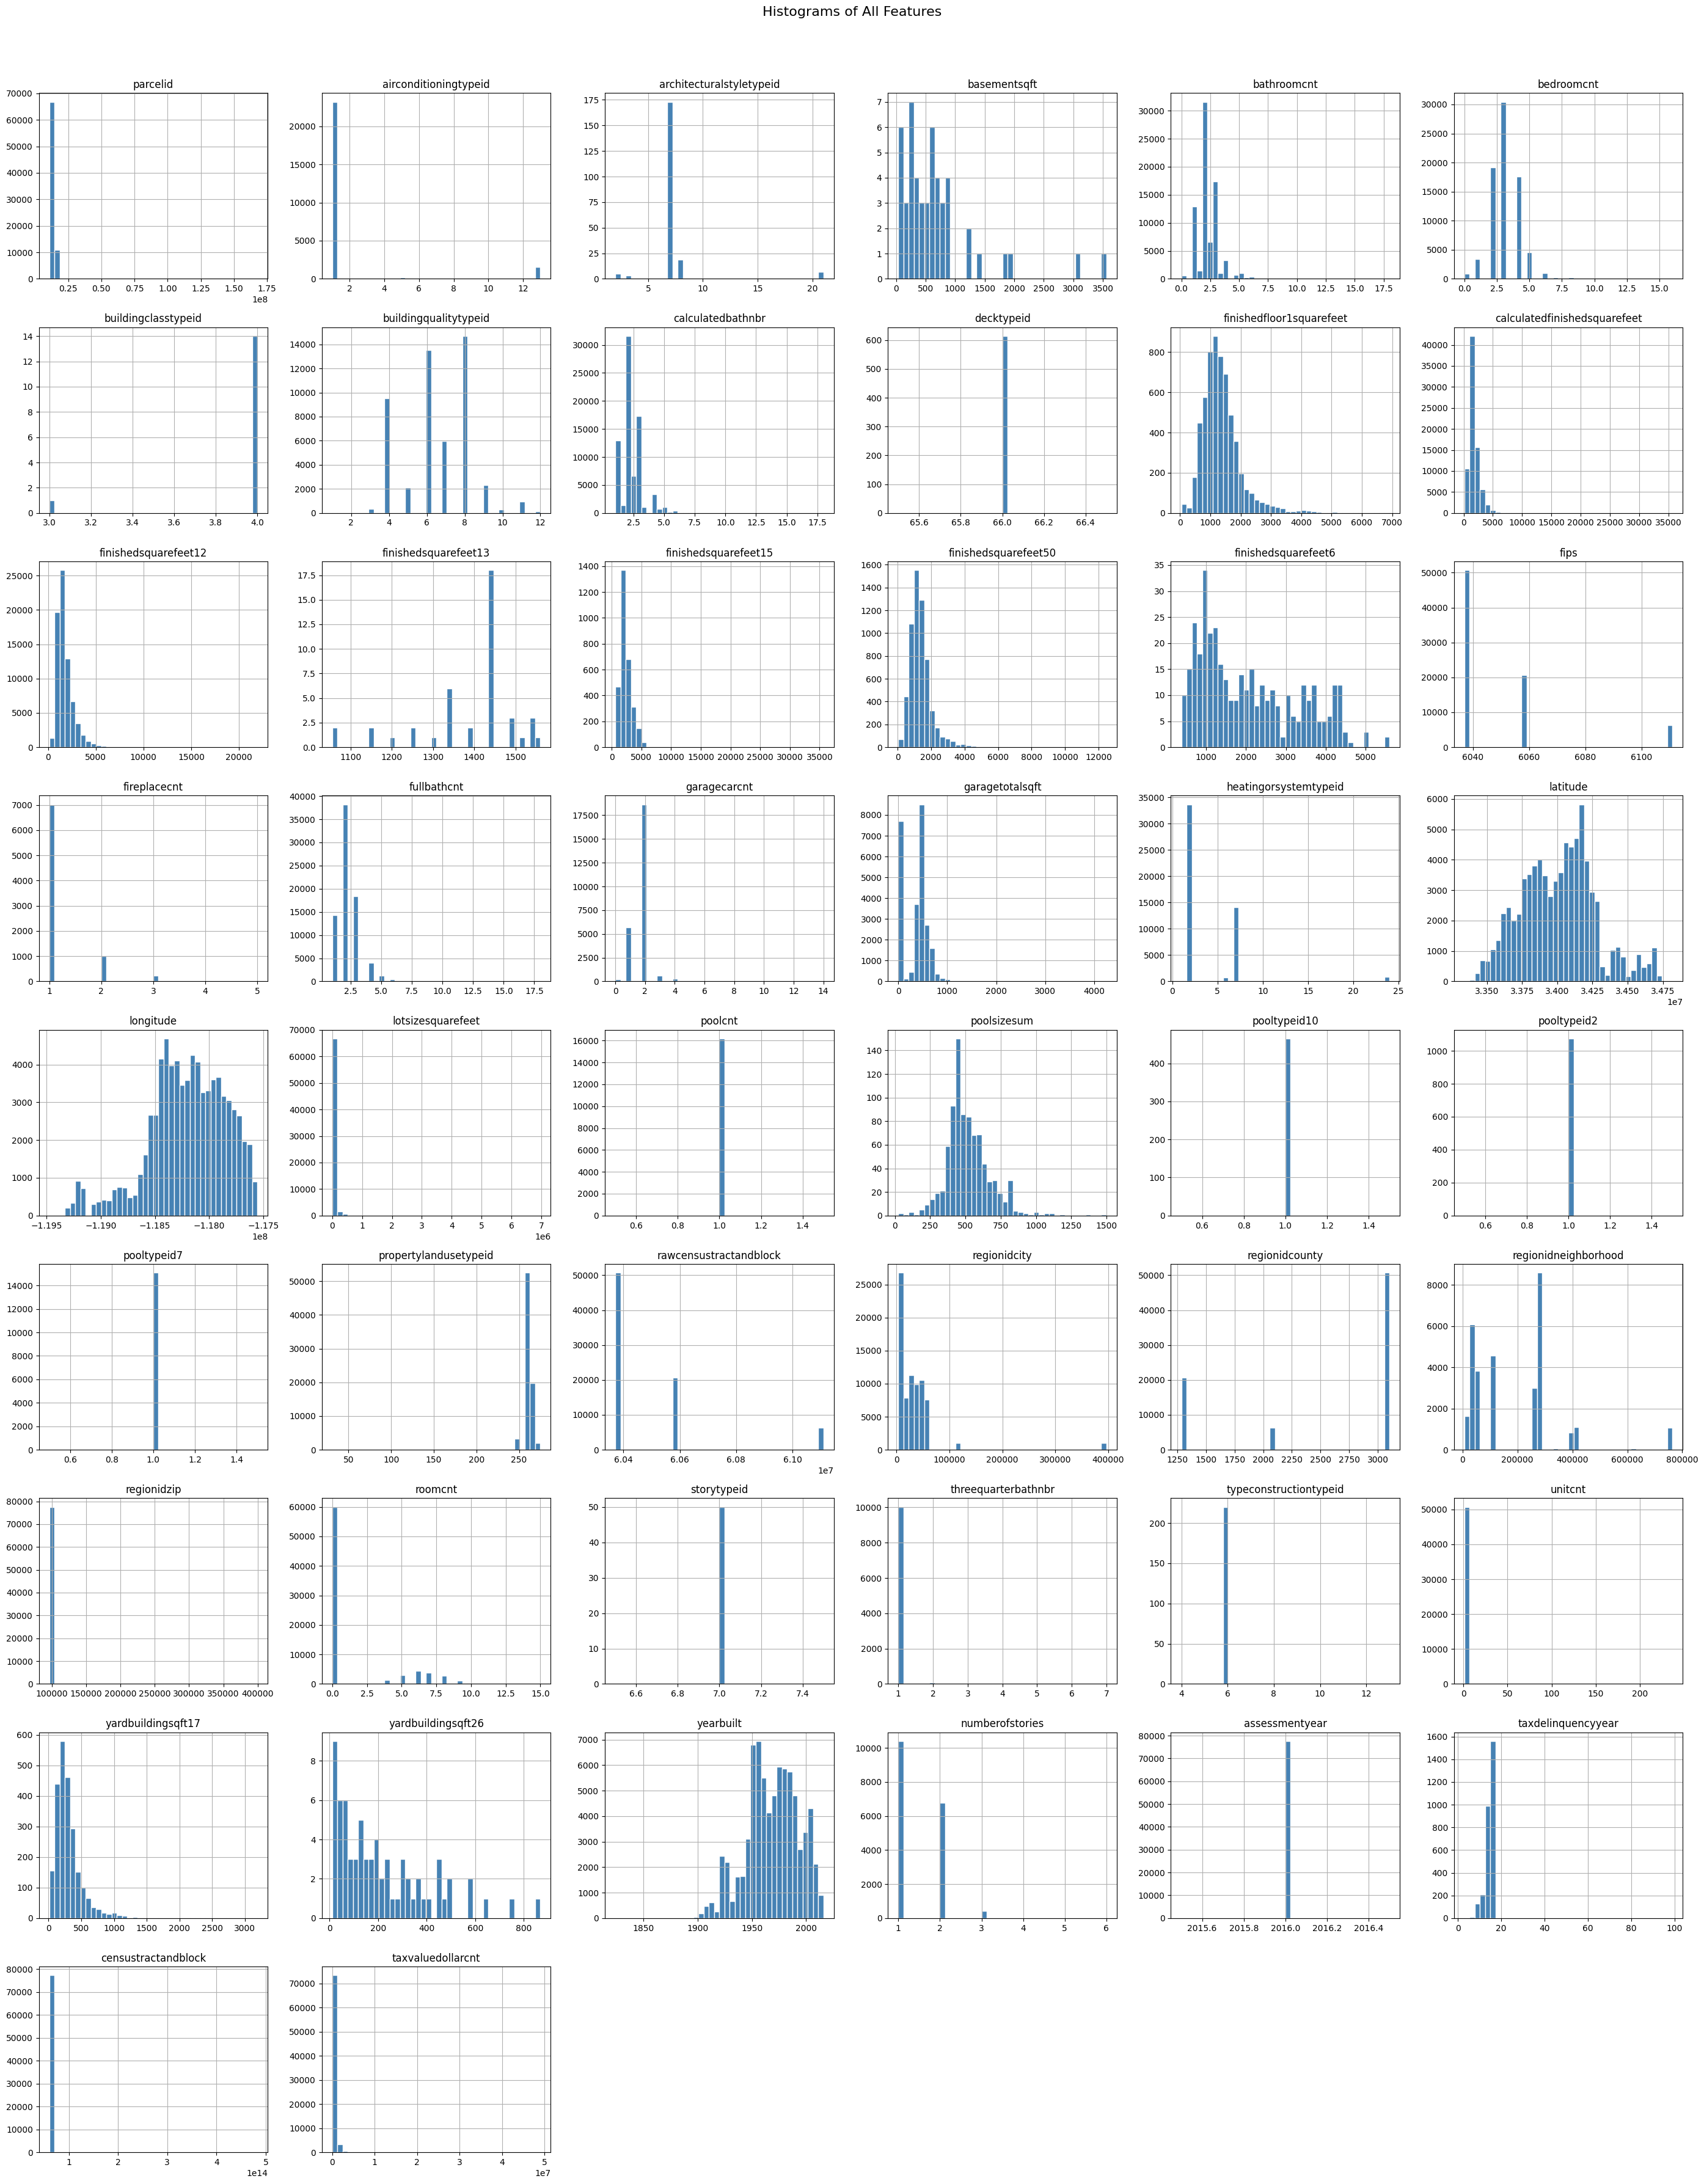

In [82]:
df.hist(figsize=(28,35), layout=(-1,6), bins=40, color='steelblue', edgecolor='white')
plt.suptitle('Histograms of All Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

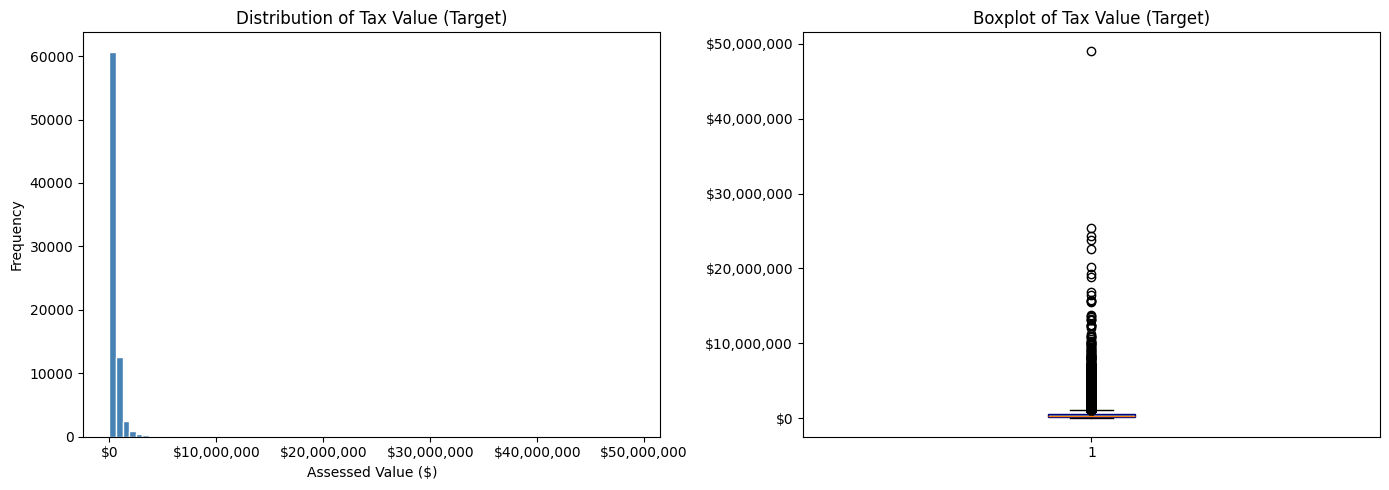

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['taxvaluedollarcnt'].dropna(), bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Tax Value (Target)')
axes[0].set_xlabel('Assessed Value ($)')
axes[0].set_ylabel('Frequency')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))

axes[1].boxplot(df['taxvaluedollarcnt'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'))
axes[1].set_title('Boxplot of Tax Value (Target)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))

plt.tight_layout()
plt.show()

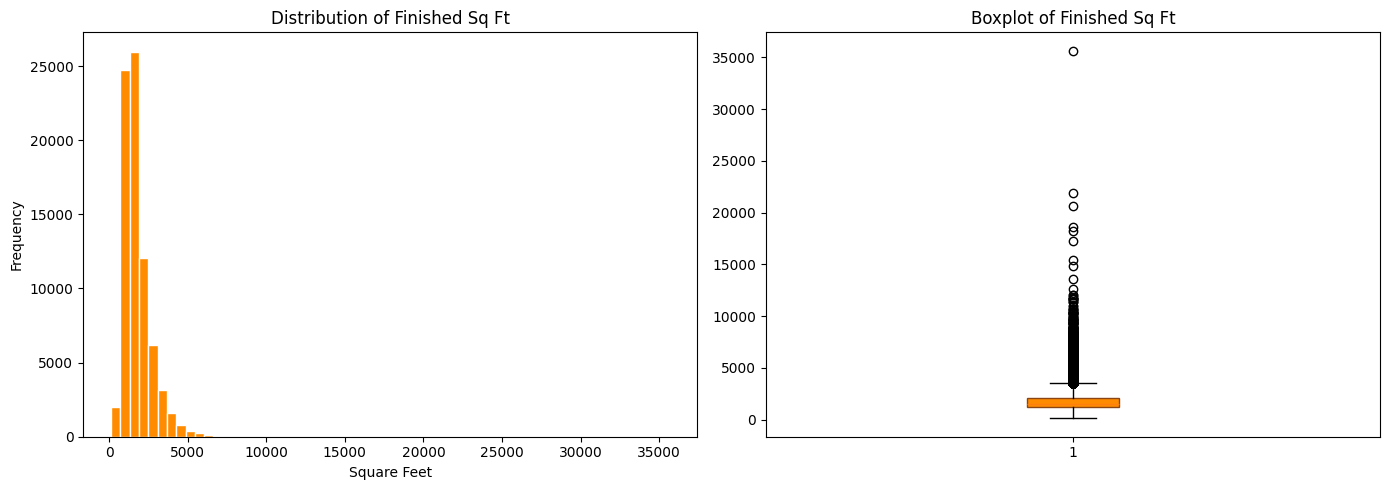

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['calculatedfinishedsquarefeet'].dropna(), bins=60, color='darkorange', edgecolor='white')
axes[0].set_title('Distribution of Finished Sq Ft')
axes[0].set_xlabel('Square Feet')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['calculatedfinishedsquarefeet'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='darkorange', color='saddlebrown'))
axes[1].set_title('Boxplot of Finished Sq Ft')

plt.tight_layout()
plt.show()

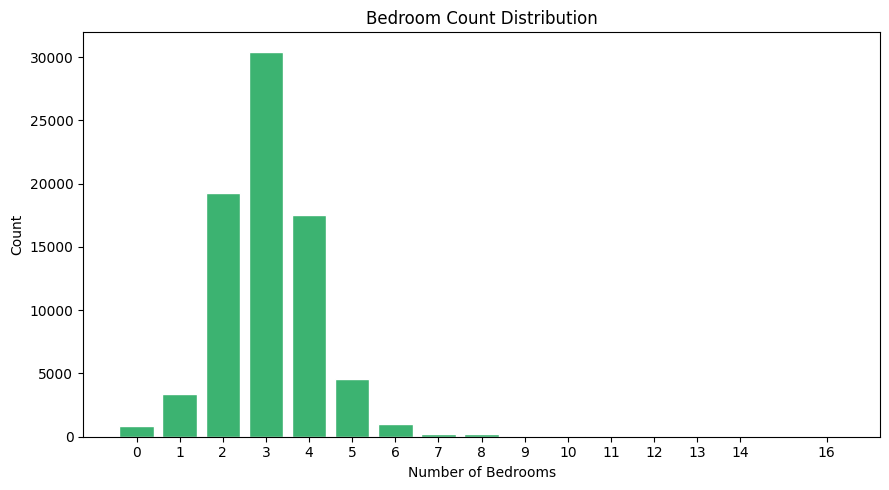

In [85]:
fig, ax = plt.subplots(figsize=(9, 5))

bedroom_counts = df['bedroomcnt'].value_counts().sort_index()
ax.bar(bedroom_counts.index, bedroom_counts.values, color='mediumseagreen', edgecolor='white')
ax.set_title('Bedroom Count Distribution')
ax.set_xlabel('Number of Bedrooms')
ax.set_ylabel('Count')
ax.set_xticks(bedroom_counts.index)

plt.tight_layout()
plt.show()

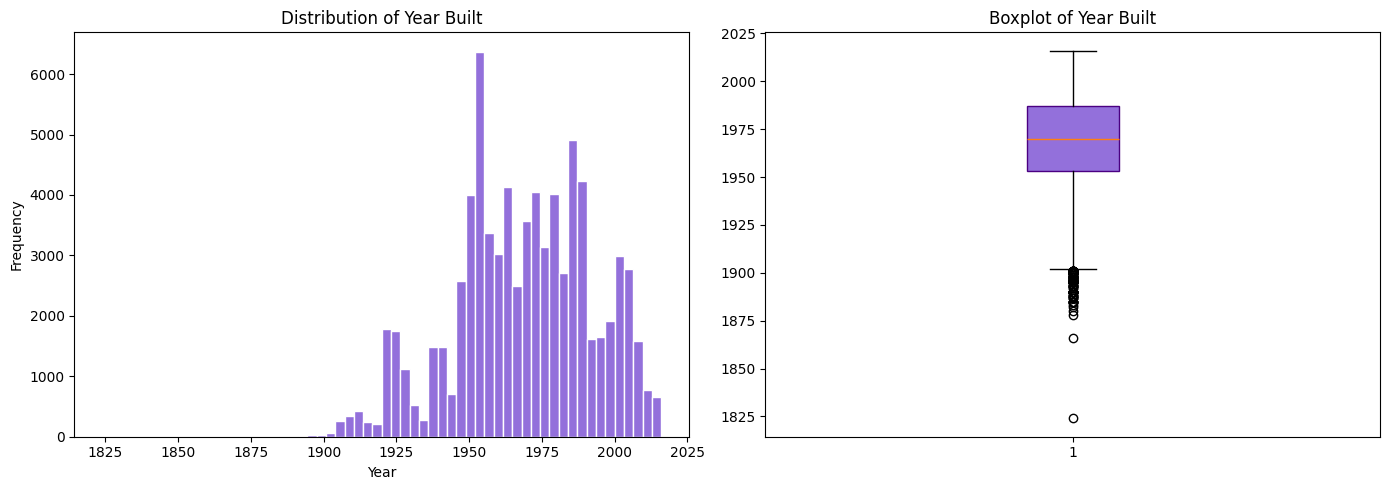

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['yearbuilt'].dropna(), bins=60, color='mediumpurple', edgecolor='white')
axes[0].set_title('Distribution of Year Built')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['yearbuilt'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='mediumpurple', color='indigo'))
axes[1].set_title('Boxplot of Year Built')

plt.tight_layout()
plt.show()

#### **2.B Discussion:** Describe in a paragraph what you learned in your detailed examination of the features you explored:
- What is the distribution (normal, exponential, etc.) if any?
- Any problems (e.g., outliers, any odd characteristics)?
- Anything else interesting? Why did you choose it?


# answer:
The target varaiable "taxvaluedollarcnt" is strongly right skewed, majority of the properties are assessed below $1 million, but the luxury properties tail stretch beyond that. The boxplot shows a lot of outliers, some properties valued in the 5 to 10 million range. This is important because it suggest a log transormation of the target may be beneficial in later modeling and the MSE will be heavily influence by those outliers.
'calculatedfinishedsquarefeet': this feature is right skewed but it is expected. The homes listed fall between 1000 and 3000 sqft, but some outliers exceed 10000. This feature will likely become the strongest predictors of tax value. 
'bedroomcnt': this was an interesting feature. the overwhelming majority of homes had 2-4 bedrooms with some outliers having 0 bedrooms (likely condos or studio apartments) and some outliers having 5 or more bedrooms, which are likely to be the luxury properties.worth investigating further.
'yearbuilt': The feature was left skewed. This showing most homes were built post WW2. these home outliers may historic homes or data entry erros, worth investigating further.

## Part 3:  Clean the Data: Drop, Impute, and Encode [6 pts]



**Important Notes:**
- You should review your Homework 4 before doing this section!
- Create new names for modified data at each stage to avoid problems with global variables.
- Whenever possible, write functions for all data transformations you apply, for these reasons:
    - So you can easily prepare the data the next time you get a fresh dataset
    - So you can apply these transformations in future projects
    - To clean and prepare new data instances once your solution is live
    - To make it easy to treat your preparation choices as hyperparameters
    - [To apply the same transformations to your test set if train/test split already done -- not applicable here]

### Part 3.A: Drop features you judge to be unsuitable for the regression task

Your call, based on any research you can do to understand the feature (hopefully IRL you would have a domain expert to help with this, but do your best).   

Note: Do not drop features because of too many missing values, that's the next task! 

In [87]:
def drop_uf(df):
    cols_drop = [
        'parcelid',
        'rawcensustractandblock',
        'censustractandblock',
        'assessmentyear',
        'taxdelinquencyflag',
        'taxdelinquencyyear',
        'regionidcounty',
        'fireplaceflag',
        'pooltypeid10',
        'pooltypeid2',
        'pooltypeid7',
        'finishedsquarefeet12',
        'decktypeid',
    ]

    df_dropped = df.drop(columns=cols_drop, errors='ignore')
    print(f"Dropped {len(cols_drop)} unsuitable featrures.")
    print(f"Shape after drop: {df_dropped.shape}")
    return df_dropped
df_3a = drop_uf(df)
df_3a.shape

Dropped 13 unsuitable featrures.
Shape after drop: (77613, 42)


(77613, 42)

#### **3.A Discussion:** Justify in a paragraph your decisions about which features to drop. 


Here when dropping the features, it was important to consider whether they were identifiers or redundant features to begin with. The row IDs have no substantial value, assessment year tracks the year of 2016 for all records which is not substantial either. Tax delinquency flag/year are the products of the tax. At the same time, pool type id and fire place flag, and finished square feet 12 are duplicates of other features. All in all most features where either duplicates or did not provide any crticial value in this dataset which was helpful for the analysis and were dropped as a result.

### Part 3.B: Drop **features** with "too many" null values

Your code in the next cell(s). Make a judgement call about what "too many" means and briefly describe your reasoning in the discussion.   

Note: "Too many" may depend on what the non-null values look like, be sure to investigate carefully. 

In [88]:
def drop_high_missing(df, threshold=0.60):
    missing_frac = df.isnull().mean()
    cols_drop = missing_frac[missing_frac>threshold].index.tolist()
    df_dropped = df.drop(columns=cols_drop)
    return df_dropped
df_3b = drop_high_missing(df_3a, threshold=0.60)
df_3b.shape    

(77613, 20)

#### **3.B Discussion:** In a paragraph, explain your decision about which features were dropped



Here the threshold was set for 60%. Any features in the dataset which had missing data more than 60% of their time means to impute here. This would not be beneficial as the data can become messy with hallucination. At the same time, features like pool cnt which was 79% missing and buliding class type id which had 100% missing were taken out. It is important to note however meatures such as building quality type id which ad not as much data missing can be more useful for impute, benifitiing the overall analysis and hence results of the data in the long run.

### Part 3.C: Drop Problematic **samples** 

There could be several reasons why you might want to drop a sample:
- It has  "too many" null values 
- It has a null value in the target
- It contains outliers, especially in the target



Your code in the next cell(s). Make a judgement call about which samples should be dropped and briefly describe your reasoning in the discussion.   


In [89]:
def drop_problematic_samples(df, target='taxvaluedollarcnt',row_null_threshold=0.50):
    Q1, Q3 = df[target].quantile(0.25), df[target].quantile(0.75)
    IQR = Q3 - Q1

    df = df.dropna(subset=[target])
    df=df[df.isnull().mean(axis=1)<= row_null_threshold]
    df=df[df[target].between(Q1-3*IQR, Q3 + 3 *IQR)]
    return df
df_3c = drop_problematic_samples(df_3b)
df_3c.shape

(75228, 20)

#### **3.C Discussion:** In a short paragraph, explain your decision about which samples were dropped


All rows which were missing more than 50% of their features, contained high outliers in the target, and did not contain any target value were considered to be removed here. As discussed before the target has right skewness which indicates that 3 with the IQR is safer to use keeping intact the information without removing any crticial ones.

### Part 3.D: Impute for the remaining missing values

Review the methods for imputation in **Appendix 2** and choose how you will impute the remainder of the missing values. Note:
- Consider whether different methods are justified for different features.
- In the next cells, apply your imputation methods to the dataset so that no null values remain after this step.
- Answer the discussion question.

In [90]:
def impute_missing_values(df):
    df=df.copy()
    num_cols = df.select_dtypes(include='number').columns.drop('taxvaluedollarcnt')
    cat_cols = df.select_dtypes(include='object').columns
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())
    df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])
    return df
df_3d = impute_missing_values(df_3c)
df_3d.shape

/tmp/ipykernel_48618/4031998375.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


(75228, 20)

#### **3.D Discussion:**  Describe in a paragraph your decisions about which methods you used to impute missing values in the dataset


Here median and mode was specifically used due to certain results dicussed before. The right skewness put a heavy emphasis on the median formualtion. Property zoning desc and property county and use code had a stronger emphasis on mode here as the most common value showcased an importance to the decisions and trends that the data was showing.

### 3.E: Encode the Categorical Features (if any)

You may not have any categorical features. If you do, encode them in the next step. No discussion is necessary. 

In [91]:
def encode_cat(df):
    return pd.get_dummies(df)
df_clean = encode_cat(df_3d)
df_clean.shape

(75228, 1961)

## Part 4:  Investigate Feature Relationships  [6 pts]

In this part, we will investigate the feature relationships as a way of understanding the data.  In the next part, we'll investigate potential feature engineering opportunities.

**Note:**  We won't be committing to any changes to the data until Milestone 2, as our choice of transformations will very much depend on the model we're building. But investigating these aspects of the data is an essential step in the first stages of our project. 

### Part 4.A:

   - Compute and analyze pairwise correlations using a correlation matrix.
   - Compute the F-statistic for all features for a better view of the relationships (displaying them in a bar chart would be useful as well). 
   - Identify features with strong correlations or notable relationships that may impact model performance.
   - Investigate forward and backward feature selection
        - Run these algorithms to investigate possible feature selection (don't commit to any selections yet)

Your code below, in multiple cells with descriptive comments. 

#### **4.A Discussion:**  Describe in a paragraph what you see in the feature relationships and correlations.

Pay particular attention to especially interesting and/or strongly correlated feature relationships. 
 How do the different methods for seeing relationships compare? Do they agree or disagree?



### Part 4.B:  2-Dimensional Visualizations for Interesting Patterns  
   - Select three (3) pairs of features that exhibit meaningful relationships based on your previous analysis. 
   - Create 2D scatter plots or density plots to explore interactions between these features.  
   - Provide brief interpretations of any observed patterns or trends. 

#### **4.B Discussion:** Provide brief interpretations of any observed patterns or trends.


## Part 5:  Feature Engineering: Investigate various transformations to better expose the underlying data patterns to machine learning algorithms. [6 pts]

**Important Notes:**  
- This last part is a bit open ended, since there is a huge variety of feature engineering techniques, most of which won't be useful for your particular dataset. 
- Understand that you can't evaluate the final usefulness of these transformations
until you choose a model, and  models may respond differently to various transformations or obviate some transformations (e.g., ensemble methods already do feature selection). 
- Therefore, write your transformations as functions or otherwise be prepared
to choose later on which transformations may be necessary. 

**Investigate feature engineering, where appropriate:**

- Feature scaling: standardize or normalize features as necessary
- Decompose features (e.g., categorical into One-Hot feature sequence, date/time into two features data and time, etc.).
- Add promising transformations of features
    - Exponential $\exp(x_i)$ or logarithmic $\log(x_j)$
    - Polynomial features  ( $x_i^2$, $x_i - x_j$), products ($x_i*x_j$), or ratios ($x_i/x_j$)

**ToDo:**
- Pick at least three transformations to try.
- Try each one and evaluate its effect using correlations or F-scores or a feature selection algorithm.
- Answer the discussion question. 

#### **5 Discussion:** Describe in a paragraph why you chose these transformations and what you observed. 


## **Appendix 1: Features of the Zillow Dataset**  

0. **parcelid**: Unique identifier for the property parcel.  
1. **airconditioningtypeid**: Identifier for the type of air conditioning installed.  
2. **architecturalstyletypeid**: Identifier for the architectural style of the property.  
3. **basementsqft**: Square footage of the basement.  
4. **bathroomcnt**: Number of bathrooms.  
5. **bedroomcnt**: Number of bedrooms.  
6. **buildingclasstypeid**: Identifier for the building framing type (e.g., wood frame, steel frame).  
7. **buildingqualitytypeid**: Numeric value indicating the quality of the building (higher values often indicate better quality).  
8. **calculatedbathnbr**: Calculated number of bathrooms, including fractional bathrooms.  
9. **decktypeid**: Identifier for the type of deck.  
10. **finishedfloor1squarefeet**: Square footage of the finished area on the first floor.  
11. **calculatedfinishedsquarefeet**: Total finished living area square footage.  
12. **finishedsquarefeet12**: Finished living area square footage.  
13. **finishedsquarefeet13**: Perimeter living area square footage.  
14. **finishedsquarefeet15**: Total area.  
15. **finishedsquarefeet50**: Square footage of the finished area on the upper floors.  
16. **finishedsquarefeet6**: Base unfinished and finished area square footage.  
17. **fips**: Federal Information Processing Standards code, uniquely identifying counties and county equivalents.  
18. **fireplacecnt**: Number of fireplaces.  
19. **fullbathcnt**: Number of full bathrooms.  
20. **garagecarcnt**: Number of cars that can fit in the garage.  
21. **garagetotalsqft**: Total square footage of the garage.  
22. **hashottuborspa**: Indicates if the property has a hot tub or spa.  
23. **heatingorsystemtypeid**: Identifier for the type of heating system.  
24. **latitude**: Latitude coordinate of the property.  
25. **longitude**: Longitude coordinate of the property.  
26. **lotsizesquarefeet**: Lot size in square feet.  
27. **poolcnt**: Number of pools on the property.  
28. **poolsizesum**: Total square footage of all pools.  
29. **pooltypeid10**: Identifier for spa or hot tub.  
30. **pooltypeid2**: Identifier for pool with spa or hot tub.  
31. **pooltypeid7**: Identifier for pool without hot tub or spa.  
32. **propertycountylandusecode**: County land use code for the property.  
33. **propertylandusetypeid**: Identifier for the property land use type.  
34. **propertyzoningdesc**: Description of the property's zoning.  
35. **rawcensustractandblock**: Unprocessed census tract and block identifier.  
36. **regionidcity**: Identifier for the city.  
37. **regionidcounty**: Identifier for the county.  
38. **regionidneighborhood**: Identifier for the neighborhood.  
39. **regionidzip**: Identifier for the ZIP code.  
40. **roomcnt**: Total number of rooms.  
41. **storytypeid**: Identifier for the type of stories in the building (e.g., basement, attic).  
42. **threequarterbathnbr**: Number of 3/4 bathrooms (typically includes a shower but no tub).  
43. **typeconstructiontypeid**: Identifier for the type of construction (e.g., frame, masonry).  
44. **unitcnt**: Number of units in the building (e.g., for multi-family properties).  
45. **yardbuildingsqft17**: Square footage of the 17th yard building (e.g., shed).  
46. **yardbuildingsqft26**: Square footage of the 26th yard building.  
47. **yearbuilt**: Year the property was built.  
48. **numberofstories**: Number of stories in the building.  
49. **fireplaceflag**: Indicates if the property has a fireplace.  
50. **assessmentyear**: Year the property was assessed.  
51. **taxdelinquencyflag**: Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty.  
52. **taxdelinquencyyear**: The year in which the property’s taxes became delinquent.  
53. **censustractandblock**: A combined identifier for the property’s census tract and block group (part of the U.S. Census geographic hierarchy).  
54. **taxvaluedollarcnt**: Total assessed value of the property (land plus structure) in dollars.  


## Appendix 2: Summary of Basic Imputation Methods
Imputation depends on the data type and context. Below are common techniques for handling missing values.

---

### **1. Simple Imputation (Basic Methods)**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Drop Missing Values** | Few missing values (<5% of data) | `df.dropna()` | Quick and easy | Can remove valuable data |
| **Mean Imputation** | Normally distributed numerical data | `df.fillna(df.mean())` | Preserves mean; simple | Distorts variance, weak for skewed data |
| **Median Imputation** | Skewed numerical data | `df.fillna(df.median())` | Robust to outliers | May not capture patterns |
| **Mode Imputation** | Categorical features | `df.fillna(df.mode().iloc[0])` | Keeps most common category | Can introduce bias |
| **Constant Value (e.g., 0)** | Special cases (e.g., unknown numerical data) | `df.fillna(0)` | Simple and interpretable | Can mislead model |
| **"Unknown" Category Imputation** (**New Addition**) | Categorical features with missing values | `df.fillna('Unknown')` | Keeps all rows, prevents data loss | May introduce artificial category |

---

### **2. Statistical & Advanced Imputation**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Interpolation** | Time series, ordered data | `df.interpolate(method='linear')` | Preserves trends | May not work for non-continuous data |
| **K-Nearest Neighbors (KNN)** | Small datasets, patterns in features | `KNNImputer(n_neighbors=5).fit_transform(df)` | Uses similar observations | Computationally expensive |
| **Multivariate Imputation (MICE)** | Complex relationships between variables | `IterativeImputer().fit_transform(df)` | Captures relationships | Slower than mean/median |
| **Regression Imputation** | When missing values depend on other variables | Train regression model to predict missing values | More accurate than mean/median | Risk of overfitting |

---

### **When to Use "Unknown" Category for Categorical Imputation**
✅ **Good for:**
- Categorical features where missing values may indicate meaningful differences.  
- Customer data (e.g., missing survey responses → "No Response").  
- Product categories where missing could be a separate group.  

❌ **Avoid if:**
- The missing category does **not** have a meaningful interpretation.
- The model might learn spurious patterns from an artificial category.

---

### **Which Method to Choose?**
| Scenario | Best Method |
|----------|------------|
| **Few missing values (<5%)** | Drop NaNs (`df.dropna()`) |
| **Numerical & normal distribution** | Mean (`df.fillna(df.mean())`) |
| **Numerical & skewed distribution** | Median (`df.fillna(df.median())`) |
| **Categorical features** | Mode (`df.fillna(df.mode().iloc[0])`) |
| **Categorical with possible meaning in missingness** | "Unknown" Category (`df.fillna('Unknown')`) |
| **Small dataset with patterns** | KNN Imputer (`KNNImputer()`) |
| **Complex relationships between features** | MICE / Iterative Imputer |

